# Phase 1 — Preparing a 2D Antiferromagnet on a Rydberg Array

**Goal:** drive a square array of Rydberg atoms into an antiferromagnetic (checkerboard) state
and measure how that order appears, reproducing the core of Scholl et al., *Nature* 595 (2021).

**The physics in one line:** each atom is a spin (ground = down, Rydberg = up). A laser sets two
knobs — the drive `Omega` (flips spins) and the detuning `delta` (energy reward for being excited).
Sweeping `delta` slowly from negative to positive carries the system across a quantum phase
transition from a disordered paramagnet into the checkerboard-ordered antiferromagnet.

**What we look at:** two *order parameters* that quantify "how checkerboard-like is the state?"
- **staggered magnetisation** `m_stag` — 0 (disordered) to 1 (perfect checkerboard). Our main, robust signal.
- **structure factor** — a correlation-based measure of the same order; richer but noisier.

**Notebook flow:** set up the atoms and pulse → watch order grow *in time* during one sweep →
scan the *final detuning* to map out the transition (the deliverable) → inspect the measured
spin patterns directly.


## 0. Imports
Local emulation only (no cloud, no credentials). `ipywidgets` powers the interactive histogram slider.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pulser
from pulser import Register, Sequence
from pulser.devices import MockDevice
from pulser.pulse import Pulse
from pulser.waveforms import RampWaveform, ConstantWaveform
from pulser.backend import BitStrings
from pulser_simulation import QutipConfig
from ipywidgets import interact, IntSlider

## 1. Helper functions

- **`staggered_magnetisation`** — main order parameter. Give each site a `+1/-1` checkerboard sign,
  measure how well the spins follow it, average over shots. 0 = disordered, 1 = perfect checkerboard.
- **`af_structure_factor`** — same order seen through spin-spin *correlations* (a Fourier component of
  the correlation function). Noisier at small system size.
- **`build_afm_sequence`** — the 3-stage sweep: (1) turn the drive `Omega` on, (2) hold it while
  sweeping `delta` across the transition, (3) turn `Omega` off to freeze in the classical pattern.


In [2]:
def central_normalized_interaction(L):
    """Interaction felt by the central atom (sets the natural detuning scale Delta1 ~ this * U)."""
    c = L // 2
    interaction = 0.0
    for i in range(L):
        for j in range(L):
            if i == c and j == c:
                continue
            dx, dy = i - c, j - c
            interaction += 1.0 / ((dx * dx + dy * dy) ** 3)
    return interaction


def staggered_magnetisation(bitstrings, L):
    """|sum_i (-1)^(i+j) z_i| / N, averaged over shots.  0 = disordered, 1 = perfect checkerboard."""
    shots = sum(bitstrings.values())
    stagger = np.array([(-1) ** (i + j) for i in range(L) for j in range(L)])
    acc = 0.0
    for b, n in bitstrings.items():
        z = 2 * np.array([int(x) for x in b]) - 1   # +1 excited, -1 ground
        acc += n * abs(np.dot(stagger, z))
    return acc / shots / (L * L)


def af_structure_factor(bitstrings, L):
    """Connected-correlation checkerboard structure factor (noisier at small L)."""
    N = L * L
    shots = sum(bitstrings.values())
    samples = []
    for b, n in bitstrings.items():
        z = 2 * np.array([int(x) for x in b]) - 1
        samples.extend([z] * n)
    samples = np.array(samples)
    connected = samples.T @ samples / shots - np.outer(samples.mean(0), samples.mean(0))
    stagger = np.array([(-1) ** (i + j) for i in range(L) for j in range(L)])
    return stagger @ connected @ stagger / (N ** 2)


def build_afm_sequence(Omega_max, t_ramp, t_hold, t_fall, Delta0, Delta1, device, reg):
    """(1) ramp Omega 0->max at Delta0; (2) hold Omega, sweep delta Delta0->Delta1 across the
       transition; (3) ramp Omega max->0 at Delta1 to project onto the classical checkerboard."""
    seq = Sequence(reg, device)
    seq.declare_channel("rydberg_global", "rydberg_global")
    seq.add(Pulse(RampWaveform(t_ramp, 0, Omega_max),
                  ConstantWaveform(t_ramp, Delta0), 0), "rydberg_global")
    seq.add(Pulse(ConstantWaveform(t_hold, Omega_max),
                  RampWaveform(t_hold, Delta0, Delta1), 0), "rydberg_global")
    seq.add(Pulse(RampWaveform(t_fall, Omega_max, 0),
                  ConstantWaveform(t_fall, Delta1), 0), "rydberg_global")
    return seq

# Cloud helper (from the demo) — reads your credentials file
import yaml
def load_pasqal_config(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

## 2. Parameters

`L` = lattice side (`N = L*L` atoms). **L=3** runs in seconds; **L=4** takes a few minutes because
exact simulation cost grows as `2**N`. `U` is the interaction energy scale (it also fixes the atom
spacing via the blockade radius); `Delta0` starts the sweep deep on the disordered side; `num_shots`
is how many times we "measure" the final state.


In [3]:
L = 3                       # atoms = L*L ; use 3 for a fast run, 4 for a cleaner lattice
Omega_max = 2.0 * np.pi * 2.0  # rad/us, peak drive
Omega_over_U = 1.3
U = Omega_max / Omega_over_U   # interaction scale

Delta0 = -3 * U                # deep paramagnetic start

t_ramp = 1000                  # ns: Omega ramp-up
t_hold = 1000                  # ns: detuning sweep (crosses the transition)
t_fall = 2000                  # ns: Omega ramp-down

num_shots = 10000              # measurements per simulation

## 3. The atoms and the target state

Lay out an `L x L` square array. The spacing is chosen so neighbours are *blockaded* — two adjacent
atoms can't both be excited — which is exactly what forces the checkerboard pattern. We also print the
two **target checkerboard states**: the antiferromagnet is a superposition of these two (one is the
other with every spin flipped), which is why we measure the *absolute* staggered magnetisation.


N = 9 atoms, spacing = 9.08 um, U = 9.67 rad/us


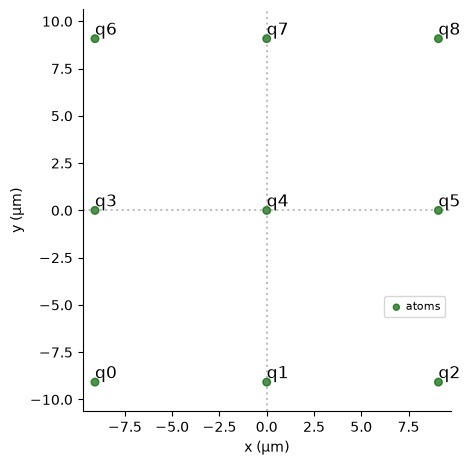


Target checkerboard states:
  010101010
  101010101  (spin-flipped)

As a 2D grid (1 = excited, 0 = ground):
[[0 1 0]
 [1 0 1]
 [0 1 0]]


In [4]:
device = MockDevice
spacing = device.rydberg_blockade_radius(U)
reg = Register.square(L, spacing, prefix="q")
print(f"N = {L*L} atoms, spacing = {spacing:.2f} um, U = {U:.2f} rad/us")
reg.draw()

# grid indices of each atom, in the SAME order as the measured bitstrings
coords = np.array([reg.qubits[q] for q in reg.qubits])
xs = np.round((coords[:, 0] - coords[:, 0].min()) / spacing).astype(int)
ys = np.round((coords[:, 1] - coords[:, 1].min()) / spacing).astype(int)
stagger_sign = (-1) ** (xs + ys)                      # +1 / -1 checkerboard sign per atom

patt = (xs + ys) % 2
afm1 = "".join(str(b) for b in patt)                  # one checkerboard
afm2 = "".join(str(1 - b) for b in patt)              # its spin-flipped partner
print(f"\nTarget checkerboard states:\n  {afm1}\n  {afm2}  (spin-flipped)")
print("\nAs a 2D grid (1 = excited, 0 = ground):")
print(patt.reshape(L, L))

## 4. The pulse sequence

Build one sweep and draw it. You should see `Omega(t)` ramp up / hold / ramp down, while `delta(t)`
stays negative, then ramps up through zero to `Delta1`. The key point: the drive is **on** while the
detuning crosses the transition — that's what lets the system follow its ground state into the ordered
phase.


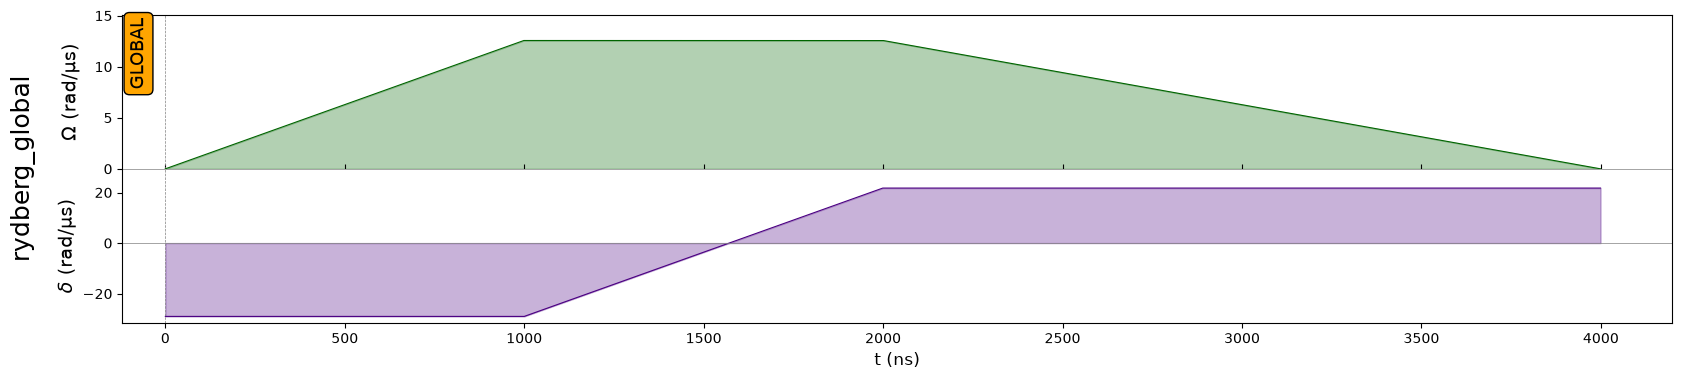

In [5]:
Delta1_max = central_normalized_interaction(L) / 2 * U   # a detuning well inside the ordered phase
seq_demo = build_afm_sequence(Omega_max, t_ramp, t_hold, t_fall,
                              Delta0, Delta1_max, device, reg)
seq_demo.draw()

## 5. Sanity check — did order form?

Run that single sweep and read the final order parameters. A high staggered magnetisation means the
antiferromagnet was successfully prepared. (Quick check before the longer runs — no graph.)


In [6]:
cfg = QutipConfig(observables=(BitStrings(evaluation_times=[1.0], num_shots=num_shots),))
res = pulser.backends.QutipBackendV2(seq_demo, config=cfg).run()
counts = res.get_result("bitstrings", res.get_result_times("bitstrings")[-1])
print(f"final staggered magnetisation = {staggered_magnetisation(counts, L):.3f}")
print(f"final structure factor        = {af_structure_factor(counts, L):.4f}")

final staggered magnetisation = 0.897
final structure factor        = 0.0784


## 6. Graph 1 — order growing *in time* during one sweep

Here we run **one** sweep to the ordered endpoint and measure the order parameter at many moments
*along the way*. This shows the antiferromagnet **forming in real time**: the staggered magnetisation
starts near its disordered floor and climbs as `delta` crosses the transition. Same physics as the
scan below, viewed along the time axis of a single sweep.


In [7]:
eval_times = np.arange(0.0, 1.01, 0.02)                  # 0 = start of sweep, 1 = end
seq_time = build_afm_sequence(Omega_max, t_ramp, t_hold, t_fall,
                              Delta0, Delta1_max, device, reg)
cfg_time = QutipConfig(observables=(BitStrings(evaluation_times=eval_times, num_shots=num_shots),))
res_time = pulser.backends.QutipBackendV2(seq_time, config=cfg_time).run()

T_total = seq_time.get_duration()
times_ns, m_time, s_time = [], [], []
for t in res_time.get_result_times("bitstrings"):
    c = res_time.get_result("bitstrings", t)
    times_ns.append(t * T_total)
    m_time.append(staggered_magnetisation(c, L))
    s_time.append(af_structure_factor(c, L))

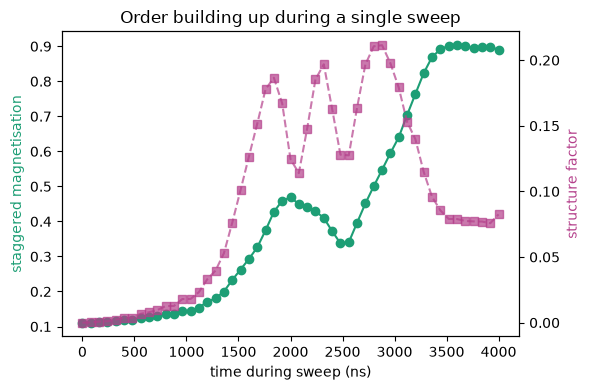

In [9]:
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(times_ns, m_time, "o-", color="#1D9E75", label="staggered magnetisation")
ax1.set_xlabel("time during sweep (ns)")
ax1.set_ylabel("staggered magnetisation", color="#1D9E75")
ax2 = ax1.twinx()
ax2.plot(times_ns, s_time, "s--", color="#B4408B", alpha=0.7, label="structure factor")
ax2.set_ylabel("structure factor", color="#B4408B")
ax1.set_title("Order building up during a single sweep")
fig.tight_layout(); plt.show()

## 7. Graph 2 — the detuning scan (**the Phase 1 deliverable**)

Now the key result. Instead of one sweep, we run **many** — each ending at a different final detuning
`Delta1` — and record only the **final** order parameter of each. Plotting order vs. `Delta1` maps out
the **quantum phase transition**: flat and low where the sweep ends on the disordered side, rising
sharply once it ends in the ordered phase. The rise location marks the transition.

Both order parameters are shown. `m_stag` (green) is the clean signal; the structure factor (magenta)
tells the same story but is sampling-noisy at small `L`.


In [10]:
delta1_scan = np.linspace(-1.5 * U, 2.5 * U, 15)          # range of final detunings to test

m_vals, s_vals = [], []
for D1 in delta1_scan:
    seq = build_afm_sequence(Omega_max, t_ramp, t_hold, t_fall, Delta0, D1, device, reg)
    cfg = QutipConfig(observables=(BitStrings(evaluation_times=[1.0], num_shots=num_shots),))
    r = pulser.backends.QutipBackendV2(seq, config=cfg).run()
    c = r.get_result("bitstrings", r.get_result_times("bitstrings")[-1])
    m_vals.append(staggered_magnetisation(c, L))
    s_vals.append(af_structure_factor(c, L))
    print(f"Delta1/U = {D1/U:+.2f}   m_stag = {m_vals[-1]:.3f}   S = {s_vals[-1]:.4f}")

Delta1/U = -1.50   m_stag = 0.112   S = 0.0003
Delta1/U = -1.21   m_stag = 0.111   S = 0.0002
Delta1/U = -0.93   m_stag = 0.113   S = 0.0012
Delta1/U = -0.64   m_stag = 0.118   S = 0.0028
Delta1/U = -0.36   m_stag = 0.144   S = 0.0199
Delta1/U = -0.07   m_stag = 0.236   S = 0.0811
Delta1/U = +0.21   m_stag = 0.425   S = 0.1268
Delta1/U = +0.50   m_stag = 0.829   S = 0.2196
Delta1/U = +0.79   m_stag = 0.953   S = 0.1753
Delta1/U = +1.07   m_stag = 0.966   S = 0.1137
Delta1/U = +1.36   m_stag = 0.973   S = 0.0985
Delta1/U = +1.64   m_stag = 0.964   S = 0.0663
Delta1/U = +1.93   m_stag = 0.931   S = 0.0651
Delta1/U = +2.21   m_stag = 0.892   S = 0.0771
Delta1/U = +2.50   m_stag = 0.872   S = 0.1437


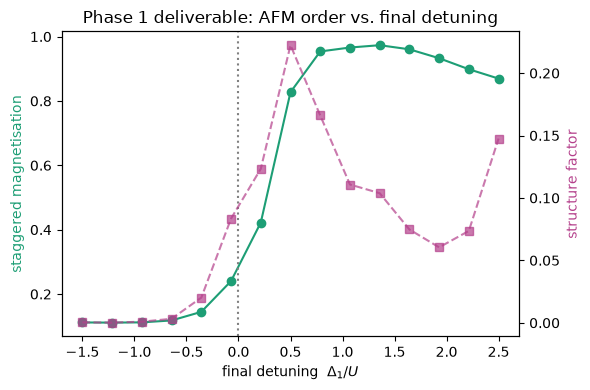

In [11]:
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(delta1_scan / U, m_vals, "o-", color="#1D9E75", label="staggered magnetisation")
ax1.set_xlabel(r"final detuning  $\Delta_1 / U$")
ax1.set_ylabel("staggered magnetisation", color="#1D9E75")
ax1.axvline(0, ls=":", color="gray")
ax2 = ax1.twinx()
ax2.plot(delta1_scan / U, s_vals, "s--", color="#B4408B", alpha=0.7, label="structure factor")
ax2.set_ylabel("structure factor", color="#B4408B")
ax1.set_title("Phase 1 deliverable: AFM order vs. final detuning")
fig.tight_layout(); plt.show()

## 8. Graph 3 — the measured spin patterns (histograms)

Finally, look at the actual measured bitstrings. We take one sweep and sample it at 11 moments; the
slider steps through them. Each bar is a measured spin configuration; bars are shaded by how
**checkerboard-like** they are (darker = closer to perfect antiferromagnetic order).

Watch the distribution move from a single tall bar at the all-ground state (start) to a cluster of
dark, checkerboard-like states (end). **Note at L=4:** the *perfect* checkerboards are rare — order
spreads across many near-perfect states with a few defects (often at the corners), which is a real
finite-size effect, not a bug. The shading makes that visible.


In [12]:
snapshot_times = np.linspace(0.0, 1.0, 11)
seq_snap = build_afm_sequence(Omega_max, t_ramp, t_hold, t_fall,
                              Delta0, Delta1_max, device, reg)
cfg_snap = QutipConfig(observables=(BitStrings(evaluation_times=snapshot_times, num_shots=num_shots),))
res_snap = pulser.backends.QutipBackendV2(seq_snap, config=cfg_snap).run()
T_total = seq_snap.get_duration()
snapshots = [(t * T_total, res_snap.get_result("bitstrings", t))
             for t in res_snap.get_result_times("bitstrings")]
print(f"Captured {len(snapshots)} snapshots.")

Captured 11 snapshots.


In [13]:
def checkerboard_score(bitstring):
    """0 = not checkerboard, 1 = perfect checkerboard (uses the register's stagger_sign)."""
    z = 2 * np.array([int(c) for c in bitstring]) - 1
    return abs(np.dot(stagger_sign, z)) / len(z)

def plot_snapshot_histogram(time_ns, counts, top_n=12):
    items = sorted(counts.items(), key=lambda kv: -kv[1])[:top_n]
    labels = [k for k, _ in items]
    values = [v for _, v in items]
    plt.figure(figsize=(9, 3.5))
    for i, (lab, val) in enumerate(zip(labels, values)):
        shade = 0.25 + 0.75 * checkerboard_score(lab)      # darker = more ordered
        plt.bar(i, val, color=plt.cm.RdPu(shade))
    plt.xticks(range(len(labels)), labels, rotation="vertical")
    plt.ylabel("counts")
    plt.title(f"Snapshot at t = {time_ns:.0f} ns   (darker = more checkerboard-like)")
    plt.tight_layout(); plt.show()

def show_snapshot(index):
    time_ns, counts = snapshots[index]
    plot_snapshot_histogram(time_ns, counts)

interact(show_snapshot,
         index=IntSlider(min=0, max=len(snapshots) - 1, step=1,
                         value=len(snapshots) - 1, description="snapshot"));

interactive(children=(IntSlider(value=10, description='snapshot', max=10), Output()), _dom_classes=('widget-in…

Here the same procedure is repeated for more quibits on the cloud

In [14]:
from pulser_pasqal import PasqalCloud
credentials_file = "credentials.example.yaml" # this part has to be changed to include credentials of the participants 
connection = load_pasqal_config(credentials_file)
connection = PasqalCloud(
    username=connection['username'],  # Your username or email address for the Pasqal Cloud Platform
    project_id=connection['project_id'],  # The ID of the project associated to your account
    password=connection['password'],  # The password for your Pasqal Cloud Platform account
)


In [15]:
# ============================================================
#  CLOUD RUN — CELL A: submit jobs (does NOT wait for results)
# ============================================================

# --- larger register ---
L_cloud = 5                                     # 25 atoms; raise to 6, 7, ...
reg_cloud = Register.square(L_cloud, spacing, prefix="q")
print(f"Cloud run: N = {L_cloud * L_cloud} atoms")

# checkerboard reference for the histogram at the new size
coords_c = np.array([reg_cloud.qubits[q] for q in reg_cloud.qubits])
xs_c = np.round((coords_c[:, 0] - coords_c[:, 0].min()) / spacing).astype(int)
ys_c = np.round((coords_c[:, 1] - coords_c[:, 1].min()) / spacing).astype(int)
stagger_sign_c = (-1) ** (xs_c + ys_c)

# --- cloud settings ---
dt = 10
num_shots_cloud = 1000
chi_main = 50                                   # bond dim for the full scan
chi_check = 100                                 # second bond dim, convergence only

delta1_scan_cloud = np.linspace(-1.5 * U, 2.5 * U, 9)
eval_times_cloud = np.arange(0.0, 1.01, 0.05)
check_idx = [3, 4, 5]                            # transition points for the convergence check

# --- submit helper ---
def submit(seq, evt, chi):
    cfg = pulser.backend.EmulationConfig(
        observables=(BitStrings(evaluation_times=evt, num_shots=num_shots_cloud),),
        dt=dt, max_bond_dim=chi)
    return pulser.backends.EmuMPSBackend(seq, config=cfg, connection=connection).run()

# --- submit everything (returns immediately; jobs run on the cloud) ---
scan_handles = []      # (Delta1, handle) at chi_main, full scan
for D1 in delta1_scan_cloud:
    seq = build_afm_sequence(Omega_max, t_ramp, t_hold, t_fall, Delta0, D1, device, reg_cloud)
    h = submit(seq, [1.0], chi_main)
    print(f"Submitted {h.batch_id}  (scan, Delta1/U = {D1/U:+.2f})")
    scan_handles.append((D1, h))

check_handles = []     # (Delta1, handle) at chi_check, transition points only
for i in check_idx:
    D1 = delta1_scan_cloud[i]
    seq = build_afm_sequence(Omega_max, t_ramp, t_hold, t_fall, Delta0, D1, device, reg_cloud)
    h = submit(seq, [1.0], chi_check)
    print(f"Submitted {h.batch_id}  (check, Delta1/U = {D1/U:+.2f})")
    check_handles.append((D1, h))

seq_t = build_afm_sequence(Omega_max, t_ramp, t_hold, t_fall, Delta0, Delta1_max, device, reg_cloud)
time_handle = submit(seq_t, eval_times_cloud, chi_main)
print(f"Submitted {time_handle.batch_id}  (time-sweep)")

print(f"\n{len(scan_handles) + len(check_handles) + 1} jobs submitted. "
      f"Check the Pasqal Cloud dashboard; run Cell B once they show DONE.")

Cloud run: N = 25 atoms
Submitted aed45998-04d7-4298-a48d-8f986e64b49c  (scan, Delta1/U = -1.50)
Submitted b33a8e98-30f6-4fd0-af74-065a4246f50d  (scan, Delta1/U = -1.00)
Submitted 89b444bc-9751-4af9-87e8-07821d68149b  (scan, Delta1/U = -0.50)
Submitted a50aa58e-996d-4199-a667-be605c16f5a0  (scan, Delta1/U = +0.00)
Submitted ccb6c6d2-57d2-4055-a1da-f2519d2ca547  (scan, Delta1/U = +0.50)
Submitted 82b3195a-3f44-44f1-b8a9-5bba7dc0a1b3  (scan, Delta1/U = +1.00)
Submitted 9583f09d-cc7d-4a19-8d9a-04d056b7eb4f  (scan, Delta1/U = +1.50)
Submitted 83998a68-44b8-4527-b0ba-0d6de398eb21  (scan, Delta1/U = +2.00)
Submitted af2cc457-41db-4865-ab23-cba7fbcfacff  (scan, Delta1/U = +2.50)
Submitted a2b8989f-d3d0-46e5-b059-9000c4d2957f  (check, Delta1/U = +0.00)
Submitted 3bf875e3-8bab-45fb-815f-52fc85da2aac  (check, Delta1/U = +0.50)
Submitted 7217e564-0797-4b57-9638-abdab51d9840  (check, Delta1/U = +1.00)
Submitted 83d2d257-8252-4766-98a9-46e93173418a  (time-sweep)

13 jobs submitted. Check the Pasqal

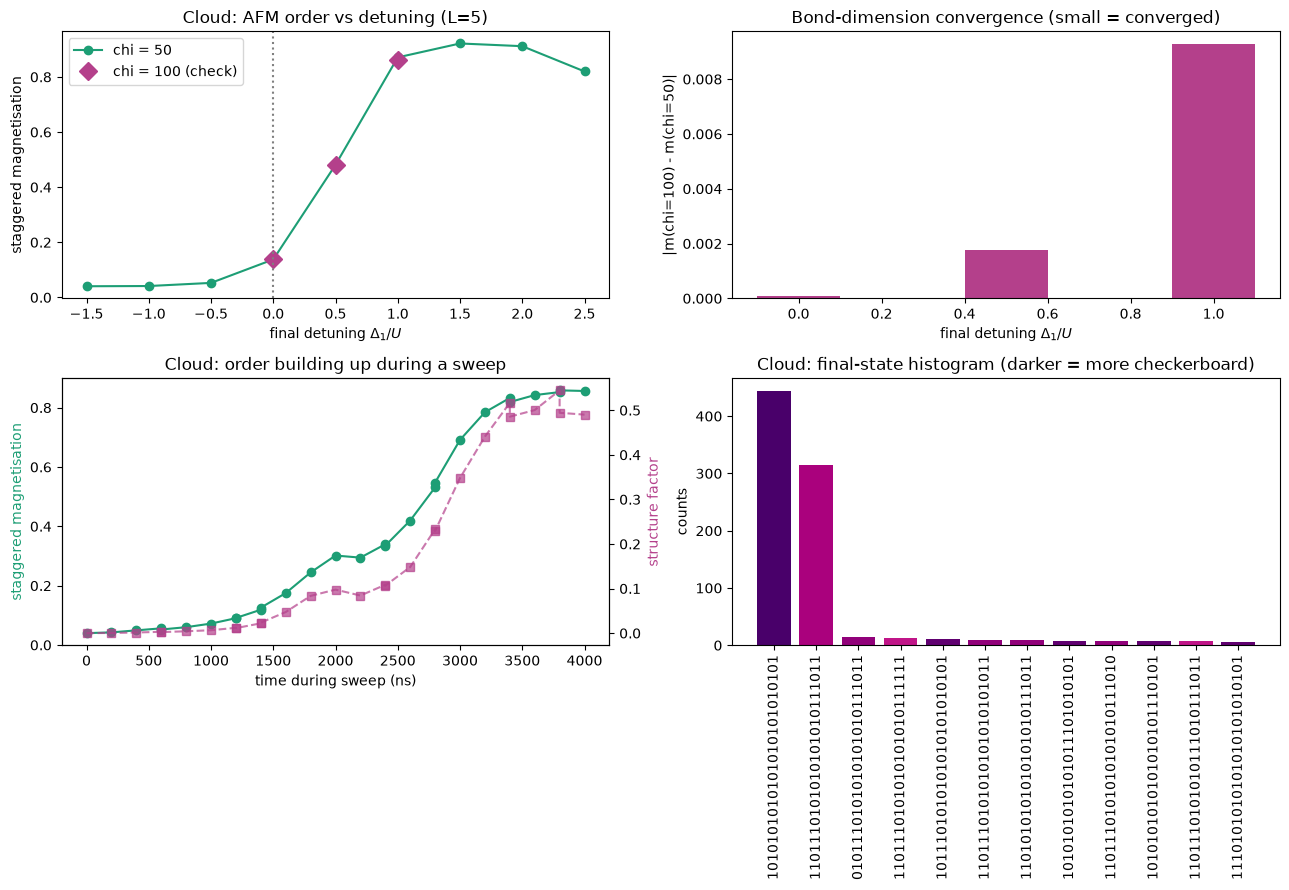

In [17]:
# ============================================================
#  CLOUD RUN — CELL B: retrieve results and plot
#  Run this only once the jobs show DONE on the cloud dashboard.
# ============================================================

# quick guard: check everything is actually done before reading
all_handles = [h for _, h in scan_handles] + [h for _, h in check_handles] + [time_handle]
statuses = [str(h.get_batch_status()) for h in all_handles]
if not all(s == "BatchStatus.DONE" for s in statuses):
    print("Not all jobs are DONE yet. Current statuses:")
    for h, s in zip(all_handles, statuses):
        print(f"  {h.batch_id}: {s}")
    raise SystemExit("Wait until all jobs are DONE, then re-run this cell.")

# ---------- collect results ----------
m_scan, s_scan = [], []
for D1, h in scan_handles:
    counts = h[-1].get_result("bitstrings", 1.0)
    m_scan.append(staggered_magnetisation(counts, L_cloud))
    s_scan.append(af_structure_factor(counts, L_cloud))

m_check = []
for D1, h in check_handles:
    counts = h[-1].get_result("bitstrings", 1.0)
    m_check.append(staggered_magnetisation(counts, L_cloud))

T_cloud = seq_t.get_duration()
times_c, m_time_c, s_time_c = [], [], []
for t in time_handle[-1].get_result_times("bitstrings"):
    c = time_handle[-1].get_result("bitstrings", t)
    times_c.append(t * T_cloud)
    m_time_c.append(staggered_magnetisation(c, L_cloud))
    s_time_c.append(af_structure_factor(c, L_cloud))

final_counts = scan_handles[-1][1][-1].get_result("bitstrings", 1.0)

# ---------- display everything together ----------
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

# (a) order vs detuning, with convergence-check points overlaid
ax[0, 0].plot(delta1_scan_cloud / U, m_scan, "o-", color="#1D9E75", label=f"chi = {chi_main}")
ax[0, 0].plot([delta1_scan_cloud[i] / U for i in check_idx], m_check, "D",
              color="#B4408B", markersize=9, label=f"chi = {chi_check} (check)")
ax[0, 0].axvline(0, ls=":", color="gray")
ax[0, 0].set_xlabel(r"final detuning $\Delta_1 / U$")
ax[0, 0].set_ylabel("staggered magnetisation")
ax[0, 0].set_title(f"Cloud: AFM order vs detuning (L={L_cloud})")
ax[0, 0].legend()

# (b) convergence: difference at the checked points (small = converged)
diffs = [abs(m_check[j] - m_scan[i]) for j, i in enumerate(check_idx)]
ax[0, 1].bar([delta1_scan_cloud[i] / U for i in check_idx], diffs, width=0.2, color="#B4408B")
ax[0, 1].set_xlabel(r"final detuning $\Delta_1 / U$")
ax[0, 1].set_ylabel(f"|m(chi={chi_check}) - m(chi={chi_main})|")
ax[0, 1].set_title("Bond-dimension convergence (small = converged)")

# (c) order building up in time
ax[1, 0].plot(times_c, m_time_c, "o-", color="#1D9E75")
ax1b = ax[1, 0].twinx()
ax1b.plot(times_c, s_time_c, "s--", color="#B4408B", alpha=0.7)
ax[1, 0].set_xlabel("time during sweep (ns)")
ax[1, 0].set_ylabel("staggered magnetisation", color="#1D9E75")
ax1b.set_ylabel("structure factor", color="#B4408B")
ax[1, 0].set_title("Cloud: order building up during a sweep")

# (d) final-state histogram, shaded by checkerboard-likeness
items = sorted(final_counts.items(), key=lambda kv: -kv[1])[:12]
for i, (lab, val) in enumerate(items):
    z = 2 * np.array([int(cc) for cc in lab]) - 1
    shade = 0.25 + 0.75 * abs(np.dot(stagger_sign_c, z)) / len(z)
    ax[1, 1].bar(i, val, color=plt.cm.RdPu(shade))
ax[1, 1].set_xticks(range(len(items)))
ax[1, 1].set_xticklabels([k for k, _ in items], rotation="vertical")
ax[1, 1].set_ylabel("counts")
ax[1, 1].set_title("Cloud: final-state histogram (darker = more checkerboard)")

fig.tight_layout()
plt.show()

## Summary

- **Graph 1 (order vs. time):** the antiferromagnet forms as the sweep crosses the transition.
- **Graph 2 (order vs. detuning):** the Phase 1 deliverable — maps the quantum phase transition; order
  is flat on the disordered side and rises where the sweep ends in the ordered phase.
- **Graph 3 (histograms):** the raw measured spin patterns, shaded by how checkerboard-like they are.

**Two order parameters, one story:** staggered magnetisation is the robust headline; the structure
factor confirms it via correlations but is noisier at small `L`.

**Next (Phase 2):** triangular lattice + the real material TmMgGaO4, switching the backend to emu-mps
for larger systems and adding a bond-dimension convergence check.


add cloud sim with more atoms and compare. 
add a thing that shows how the histogran computes the mstagg and factor